In [57]:
import requests, json, re
import pandas as pd
import numpy as np
import decimal
import time
from datetime import datetime, timedelta
from rich import print
import os
import base64
import sys

from dotenv import load_dotenv
#from dash import Dash, dcc, html, Input, Output
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from collections import defaultdict
import plotly.graph_objects as go
# Load environment variables from .env file
load_dotenv()

api_key= os.getenv('taostats_api')

headers = {
            "accept": "application/json",
            "Authorization": api_key
        }
#colours
ts_teal = '#00DBBC'
ts_red ='#EB5347'
ts_yellow ='#EBC247'
ts_orange ='#FF8B25'
ts_purple ='#D65BB3'
ts_lblue ='#47C6EB'
ts_fusia ='#E82166'
ts_lime ='#BAEB47'
ts_sand ='#EB7347'
ts_dpurple ='#9747FF'
ts_pblue ='#87FFEE'
ts_dgreen ='#007564'
ts_gray ='#909090'
ts_green ='#00B20F'
ts_brown ='#BD7536'
ts_rblue ='#008BDB'
#plot in dark mode
plt.style.use('dark_background')
NODE_COLORS = ['#00DBBC','#EB5347','#EBC247','#FF8B25','#D65BB3','#47C6EB','#E82166','#BAEB47','#EB7347','#9747FF','#87FFEE','#007564','#909090','#00B20F','#BD7536','#008BDB']

In [58]:
def get_current_block():
    url = "https://api.taostats.io/api/block/v1?network=finney&page=1&limit=1"
    response = requests.get(url, headers=headers)
    resJson = json.loads(response.text)
    cb = resJson['data'][0]['block_number']
    return cb

In [59]:
total_alpha = {}
url = "https://api.taostats.io/api/dtao/pool/latest/v1"

response = requests.get(url, headers=headers)
resJson = json.loads(response.text)

subnets= resJson['data']

for subnet in subnets:

    netuid = subnet['netuid']
    alpha = float(subnet['total_alpha'])/1e9
    total_alpha[netuid]= alpha

In [60]:
max_alpha_day = (0.5 +1)*7200
min_alpha_day = 7200


In [61]:
block_end = get_current_block()
block_start =block_end-400
subnet_alphas = {}
subnet_halving_days = {}
fastest = 1e9
longest = 0
current = 1e9

url = f"https://api.taostats.io/api/dtao/subnet_emission/v1?block_start={block_start}&block_end={block_end}&limit=200"
response = requests.get(url, headers=headers)
resJson = json.loads(response.text)
subnets= resJson['data']

for subnet in subnets: 
    netuid = subnet['netuid']
    a_in = float(subnet['alpha_in_pool'])/1e9
    a_out = float(subnet['alpha_rewards'])/1e9
    a_total = a_in +a_out
    a_total_day = a_total*7200
    subnet_alphas[netuid] = a_total_day
    

    #now we can math the subnet halving days
    if netuid > 0:
        alpha_to_emit = 10500000 - total_alpha[netuid]
        earliest_halving = round(alpha_to_emit/max_alpha_day,1)
        current_halving = round(alpha_to_emit/a_total_day,1)
        latest_halving = round(alpha_to_emit/min_alpha_day,1)
        subnet_halving_days[netuid] = [earliest_halving, current_halving,latest_halving]

        fastest = min(fastest, earliest_halving)
        current = min(current, current_halving)
        longest = max(longest,latest_halving)
    

In [62]:
print(fastest, current, longest)
print(fastest/365, longest/365)

print(block_end, block_start)
print(len(subnet_halving_days))


481.1 501.5 1435.7

1.318082191780822 3.9334246575342466

8182593 8182193

128

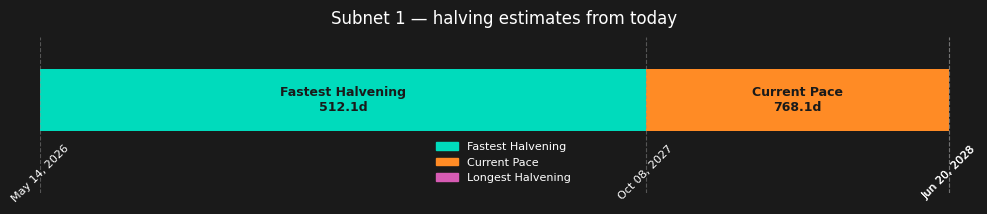

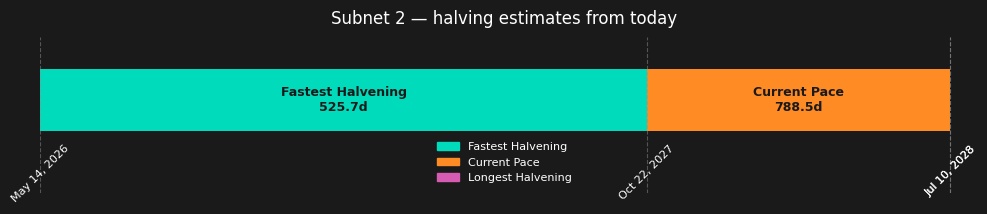

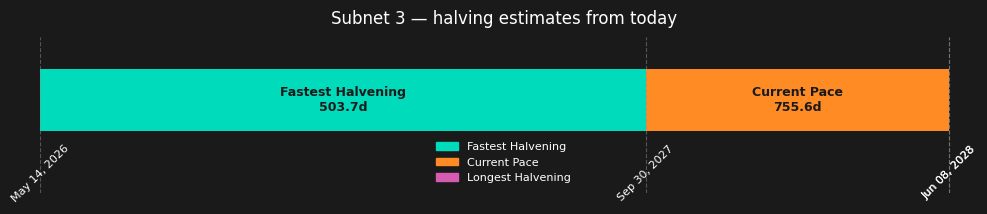

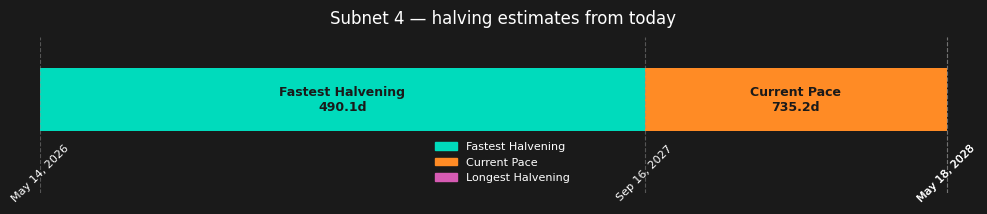

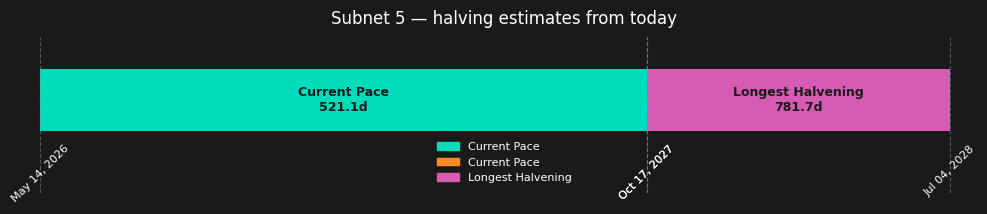

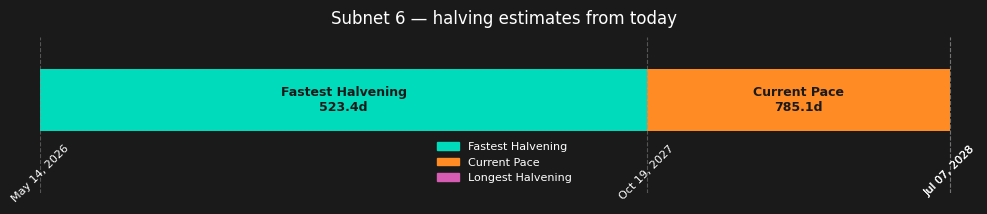

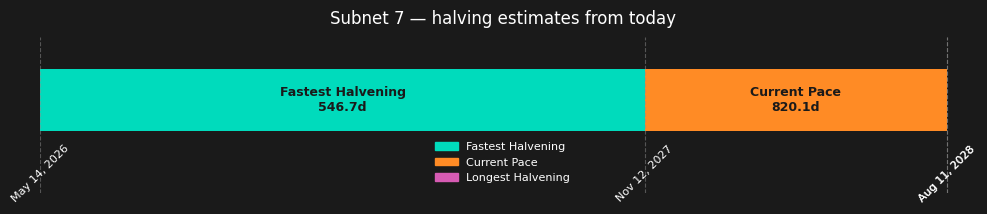

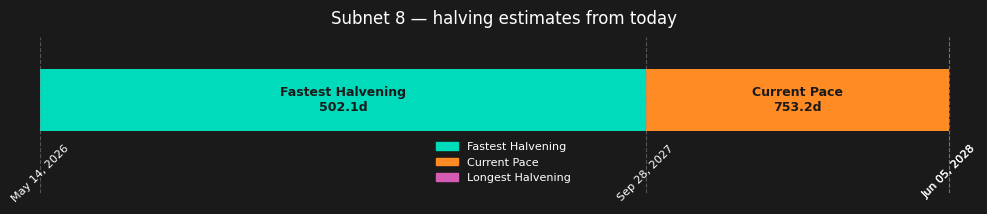

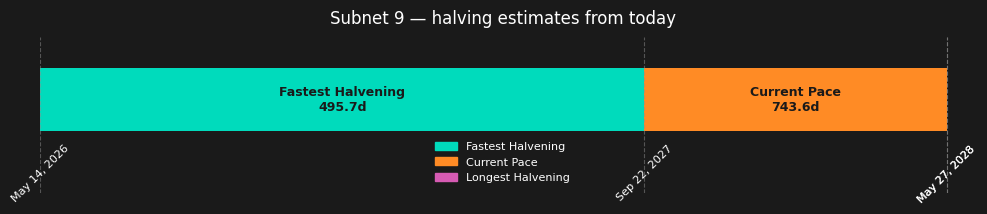

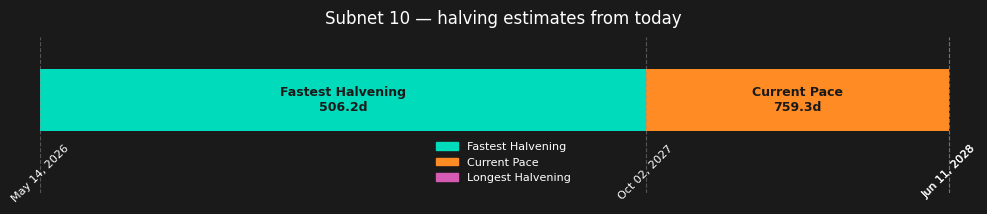

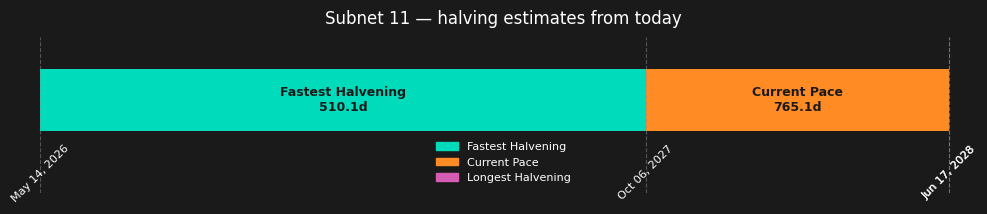

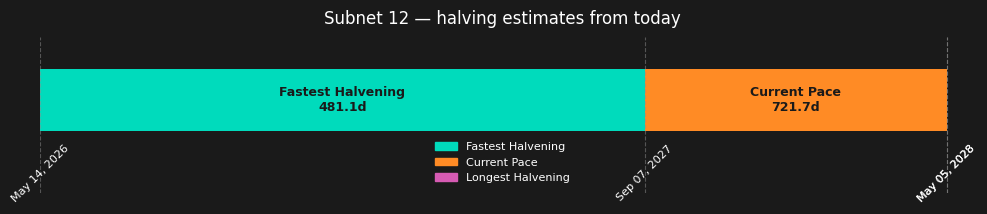

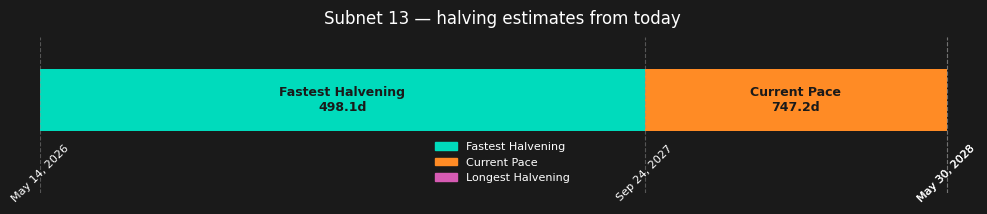

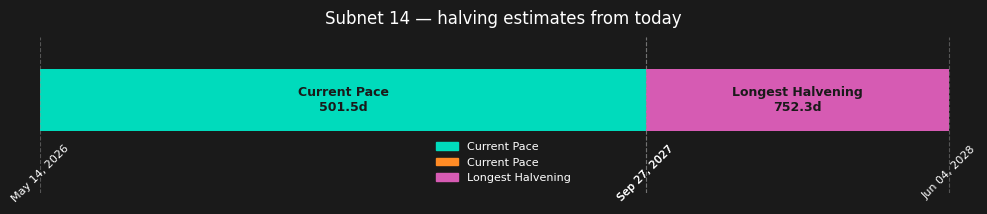

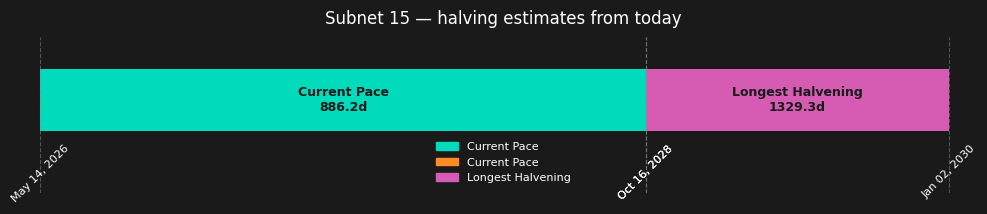

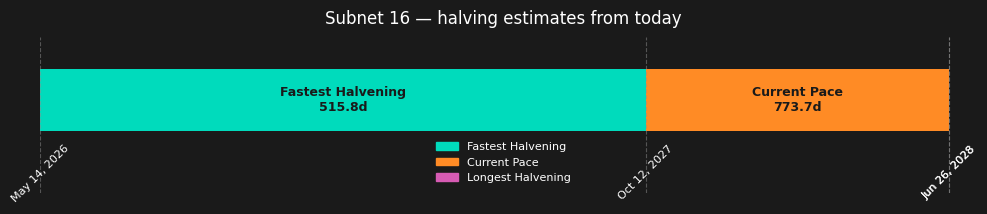

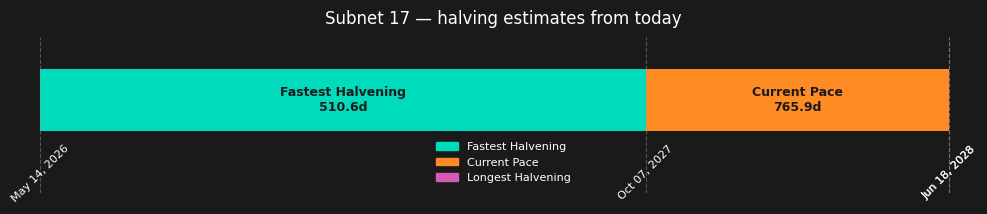

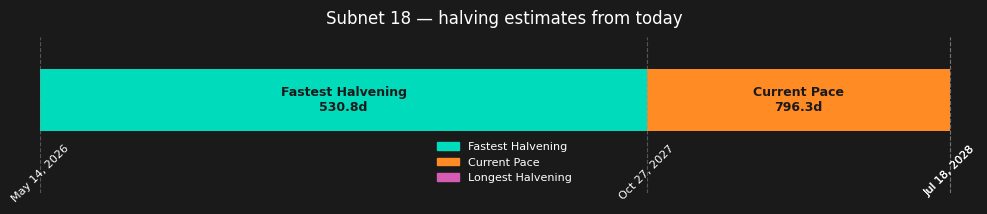

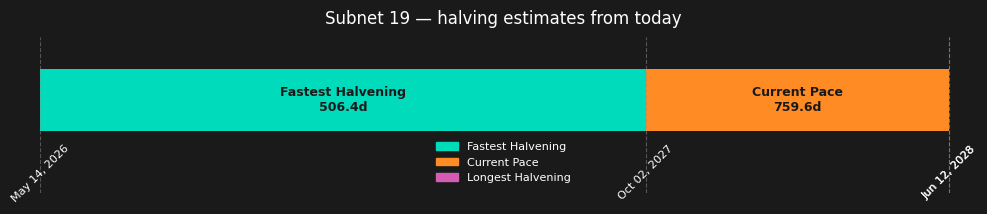

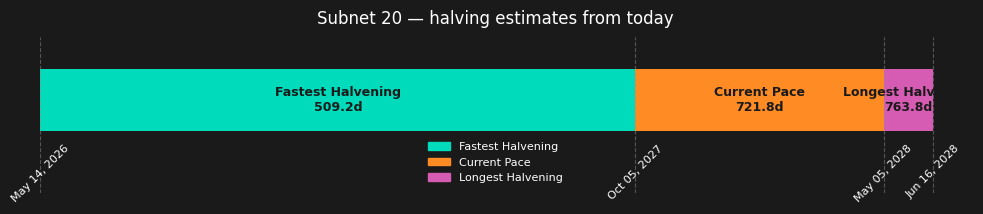

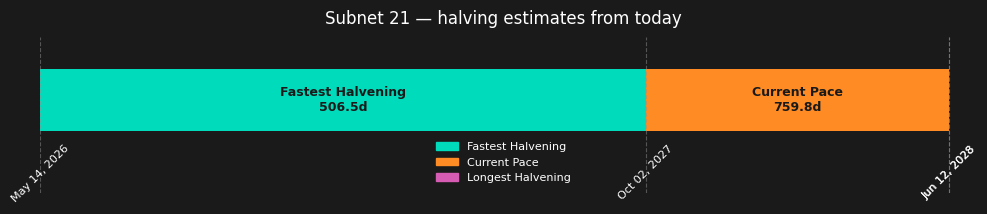

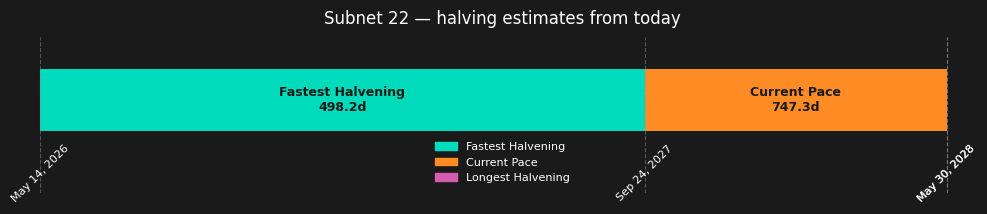

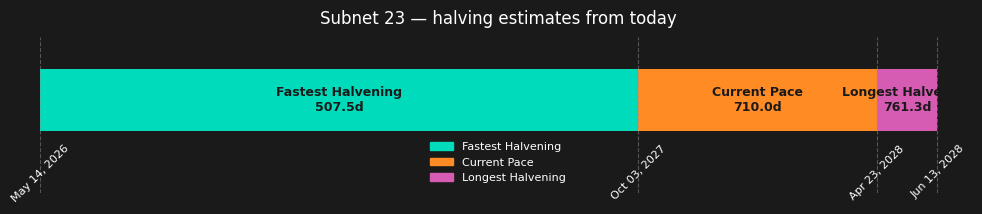

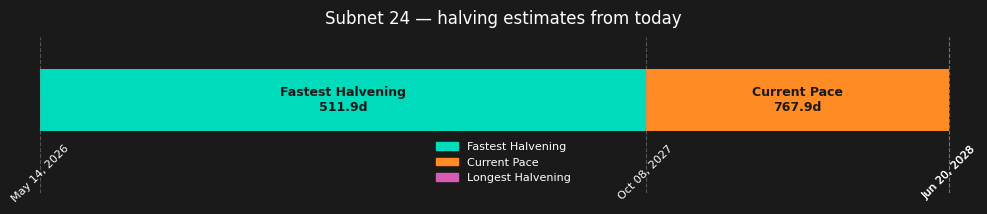

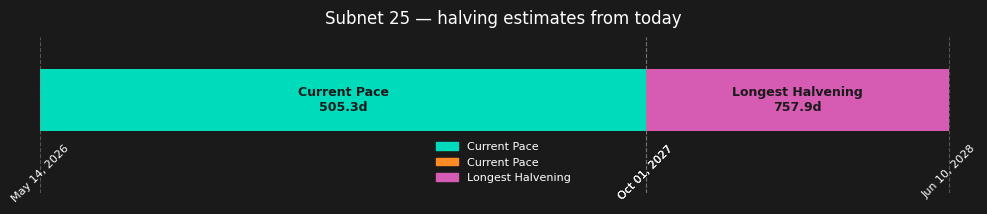

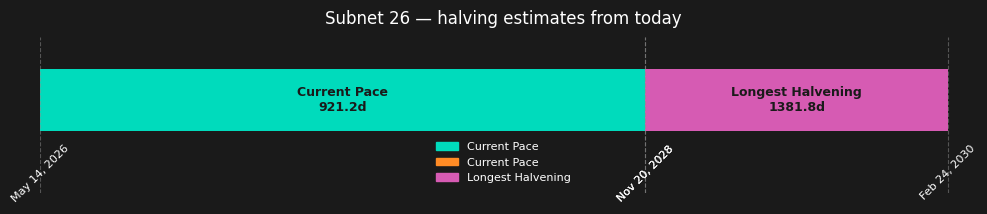

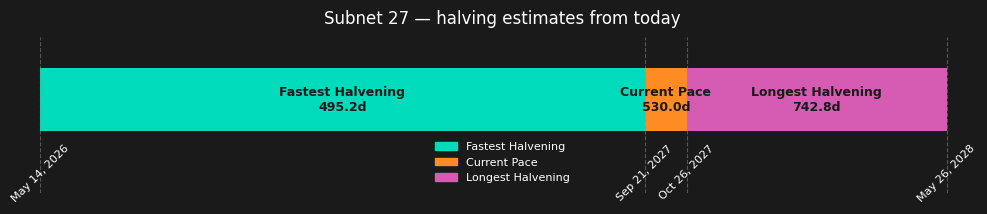

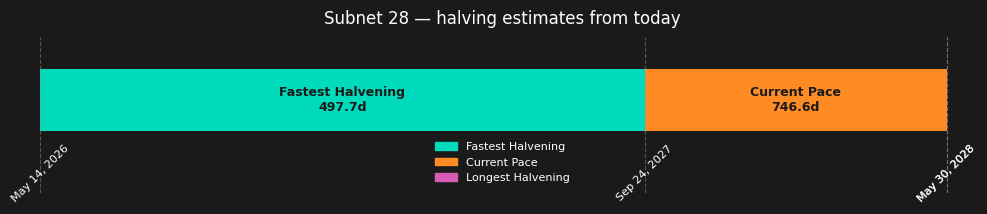

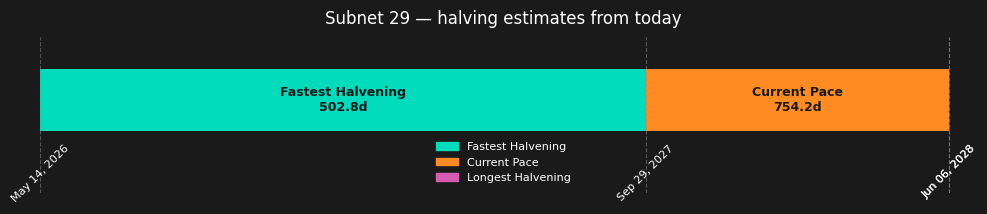

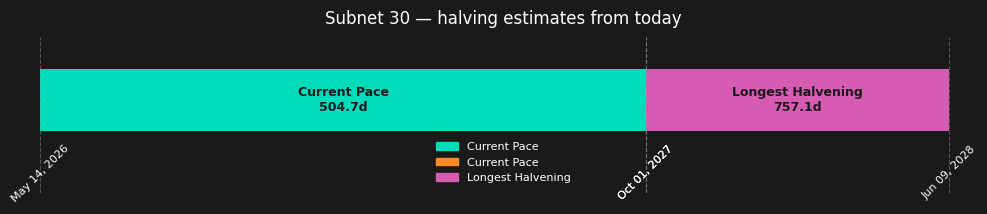

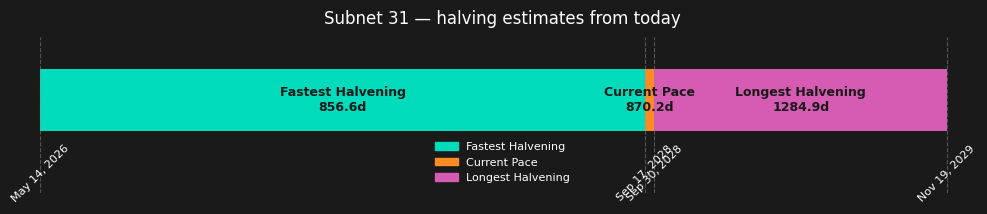

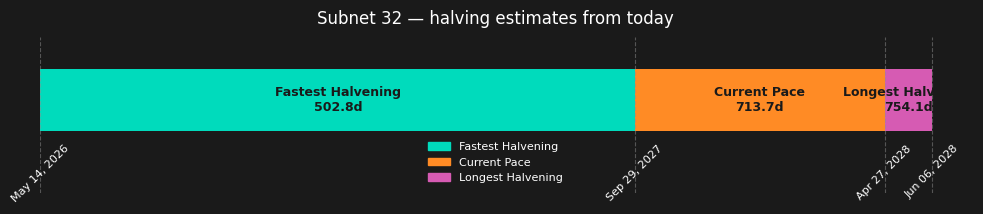

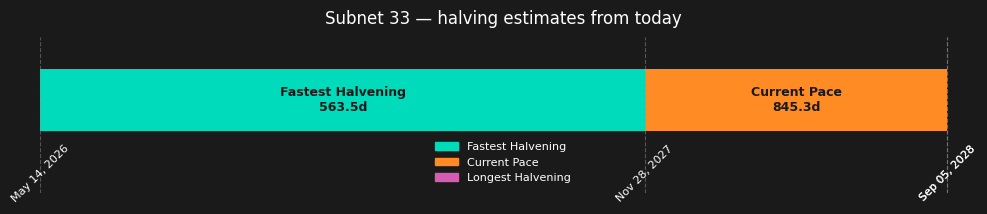

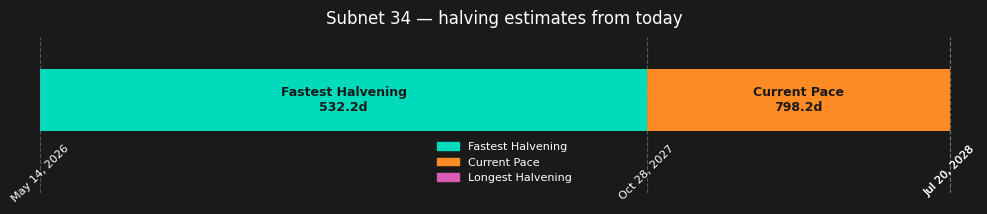

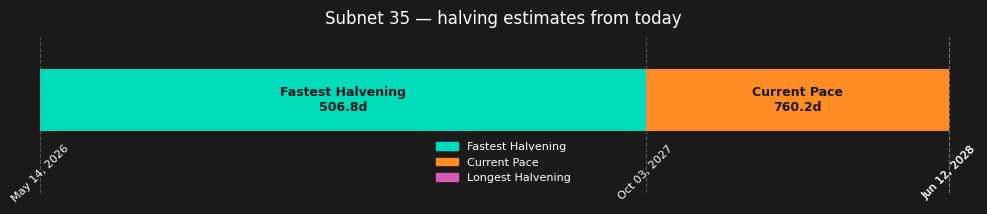

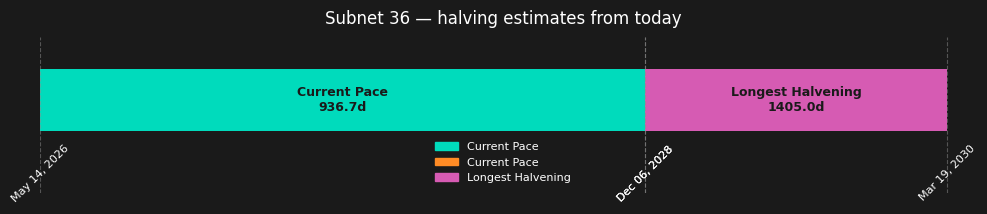

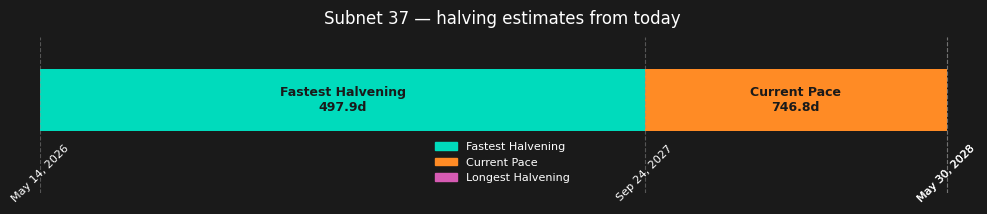

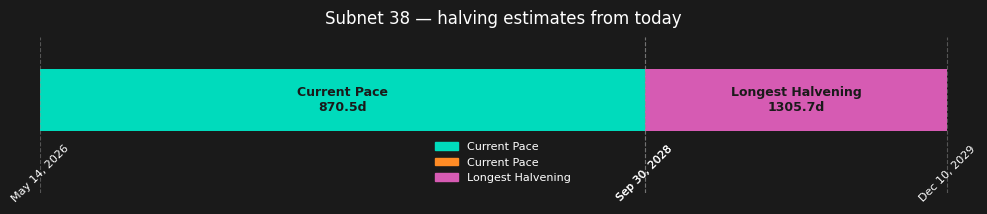

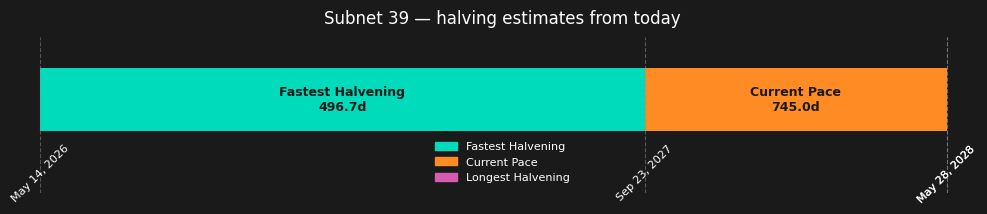

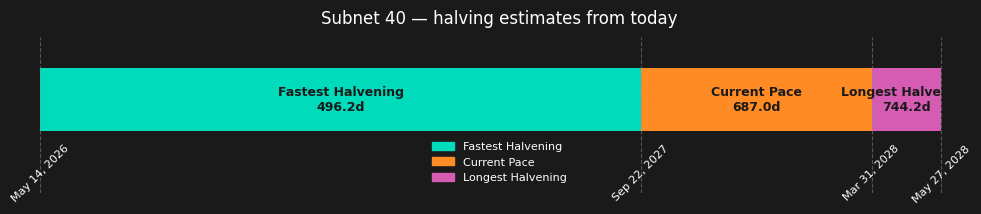

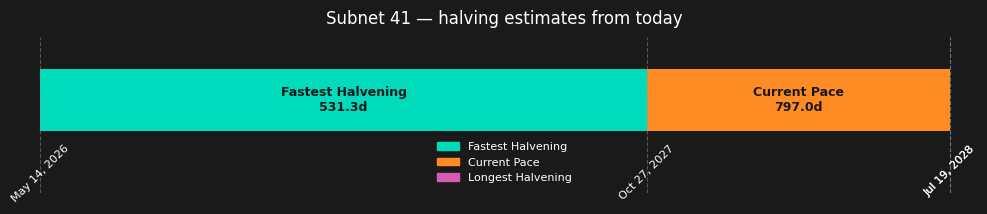

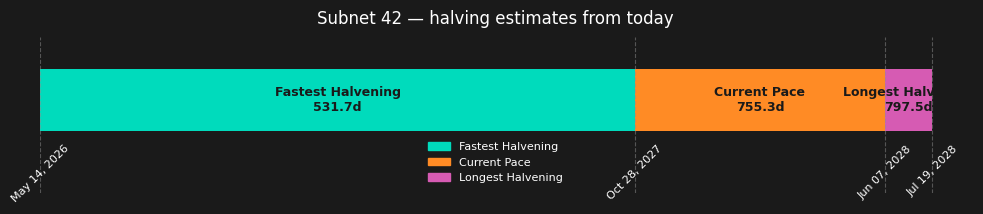

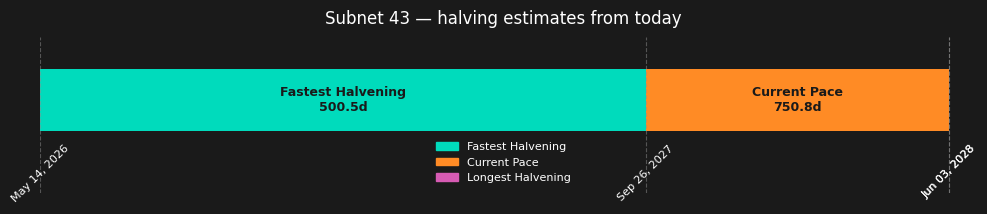

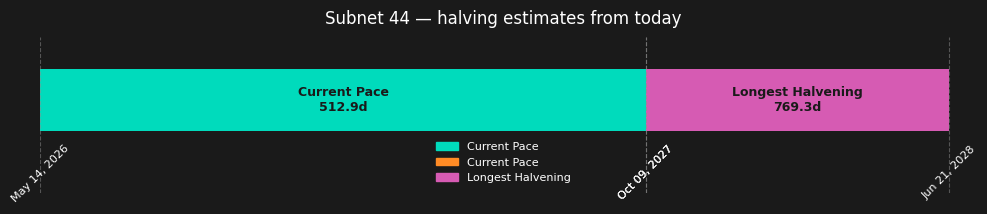

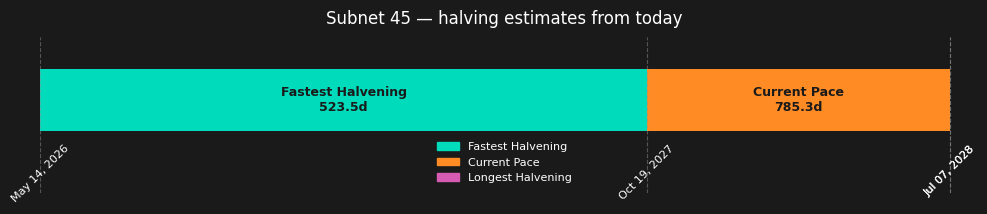

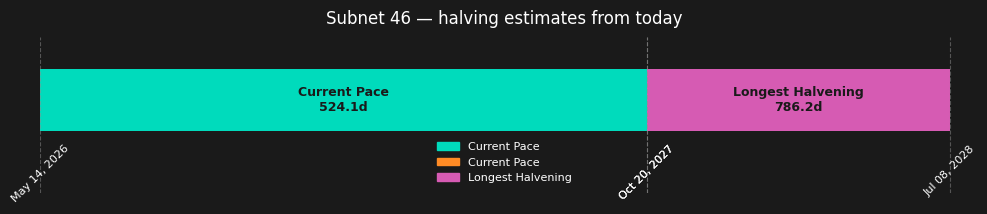

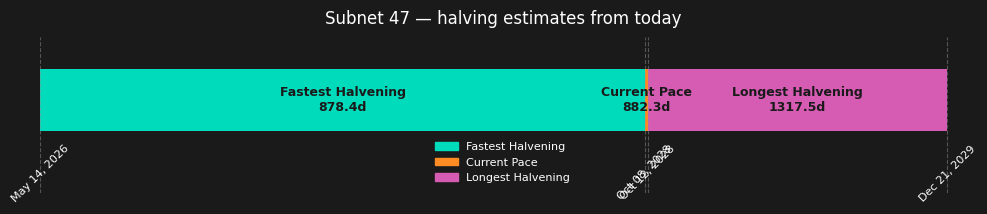

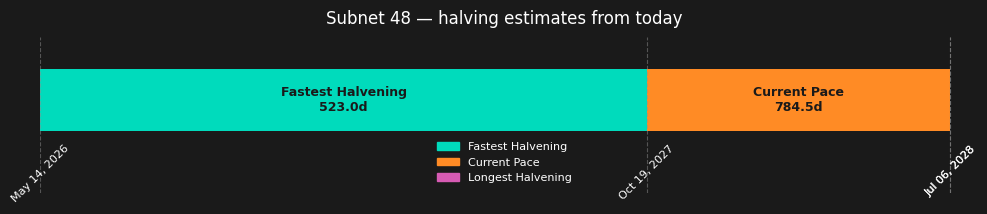

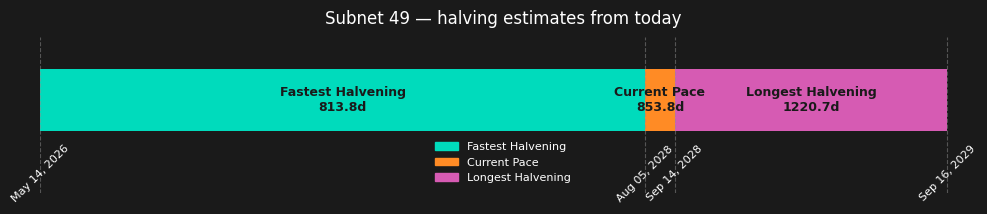

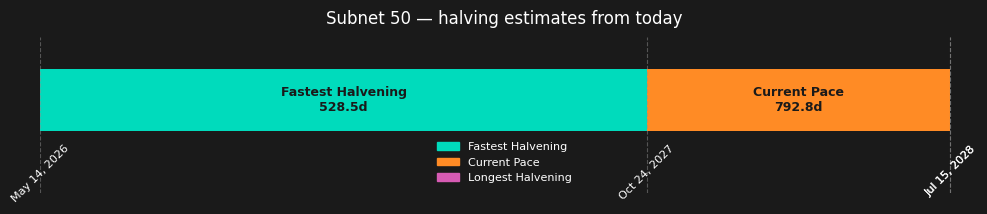

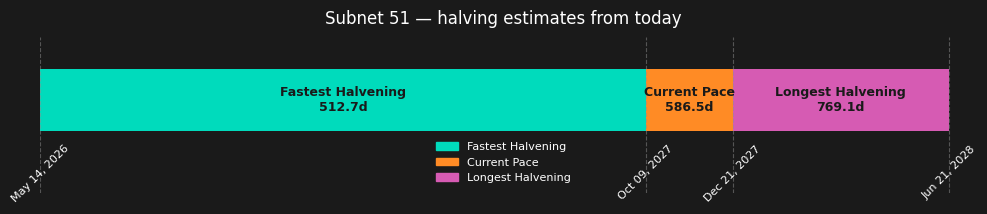

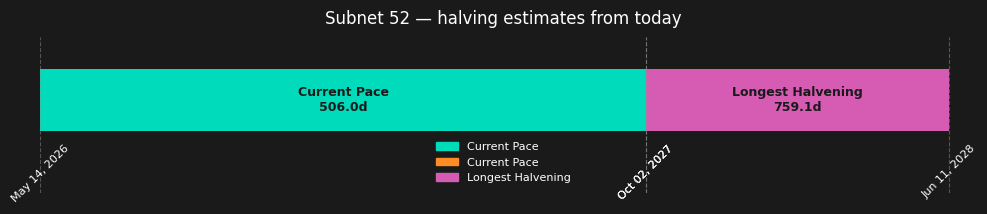

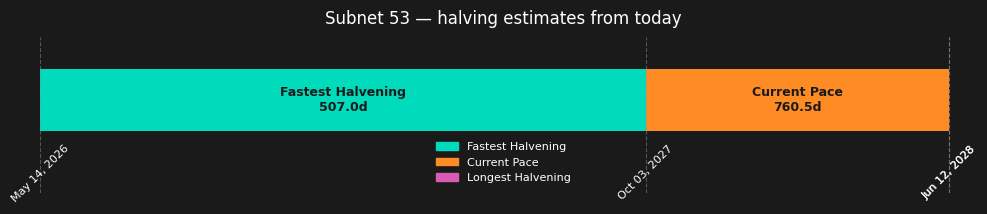

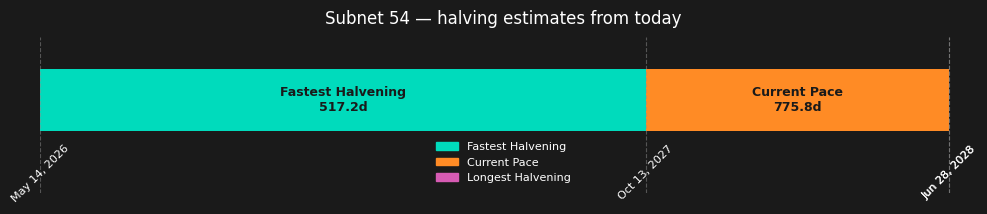

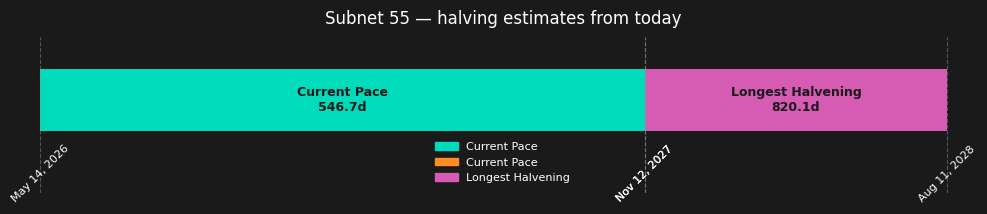

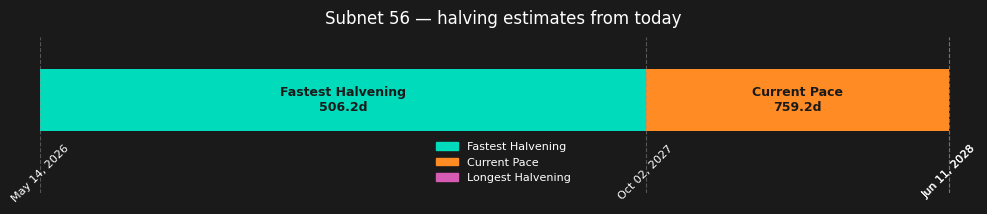

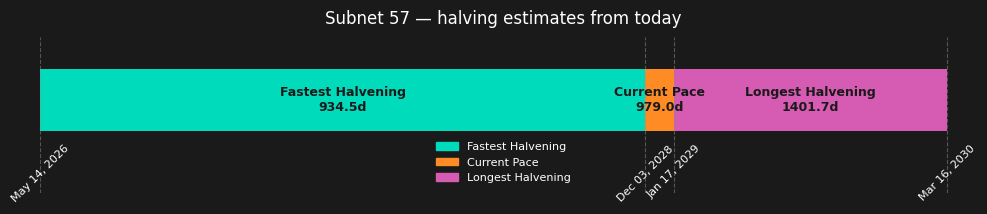

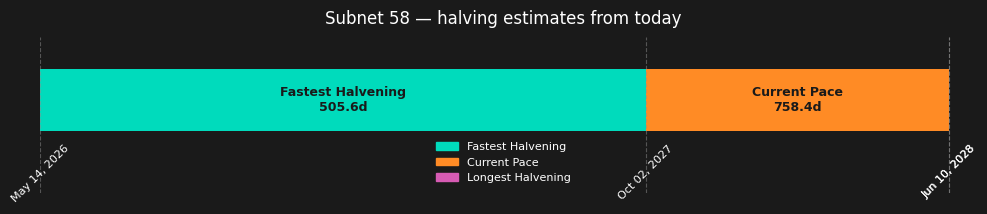

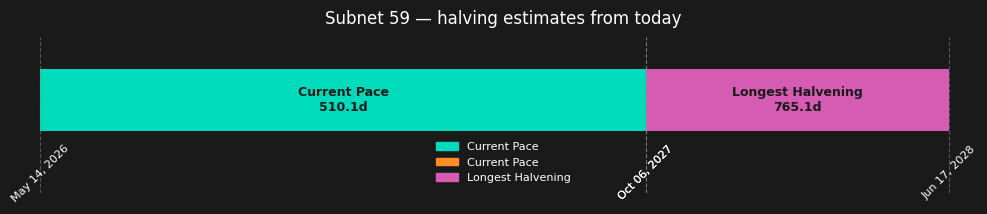

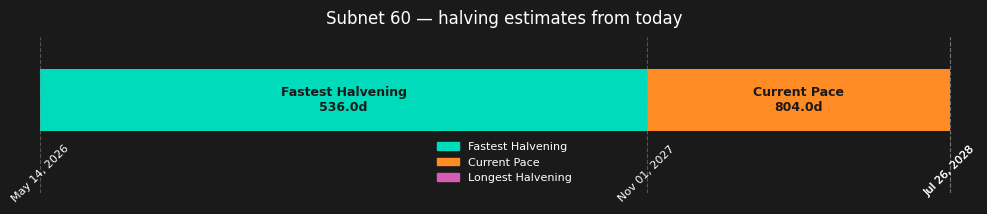

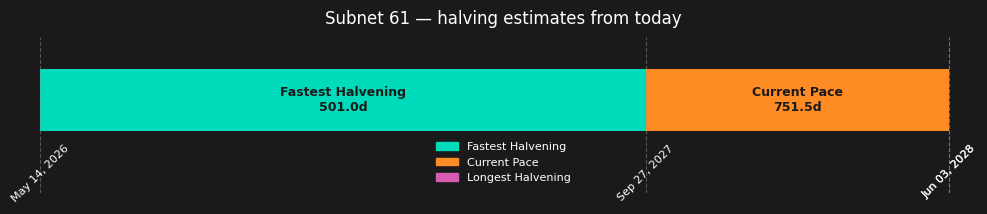

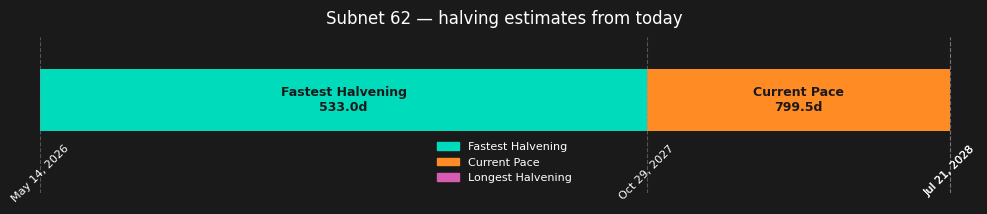

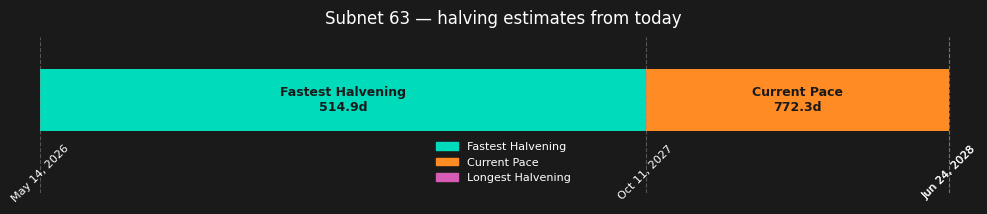

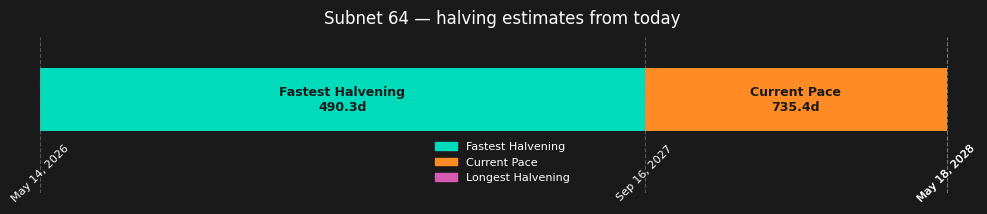

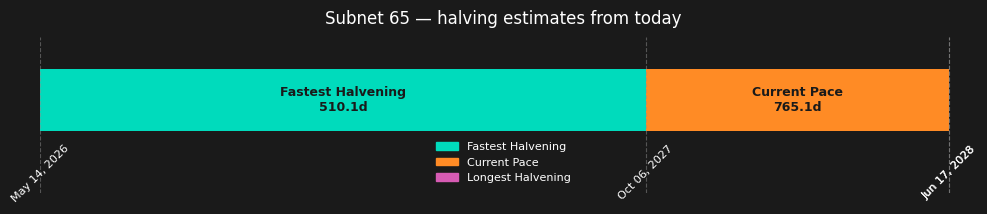

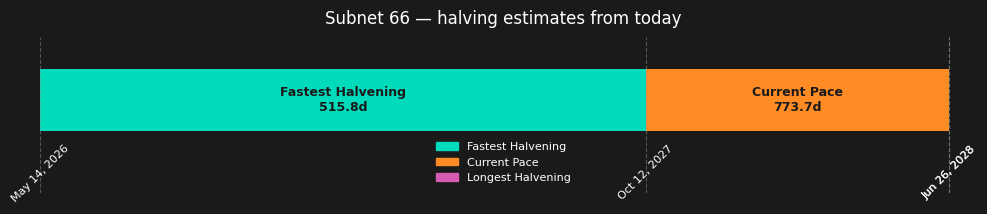

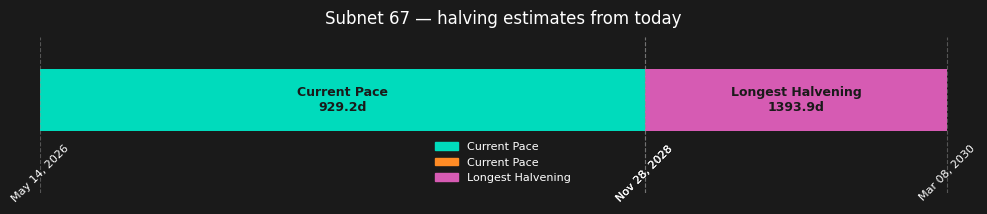

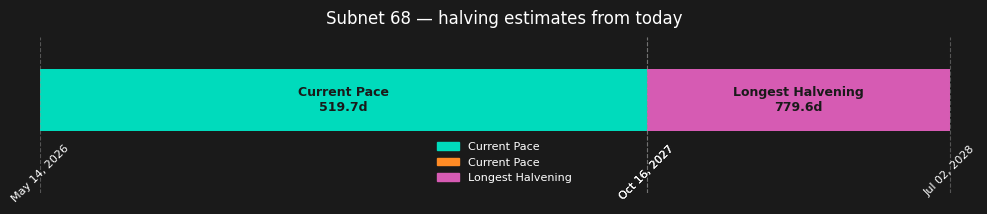

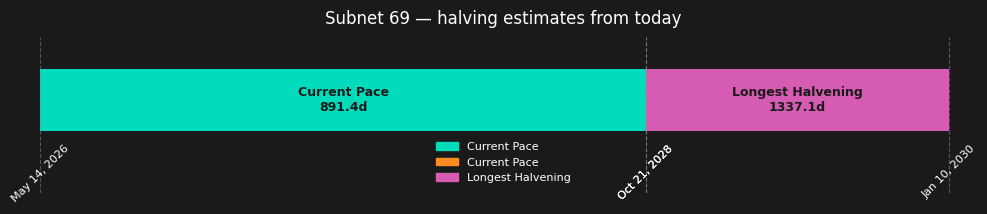

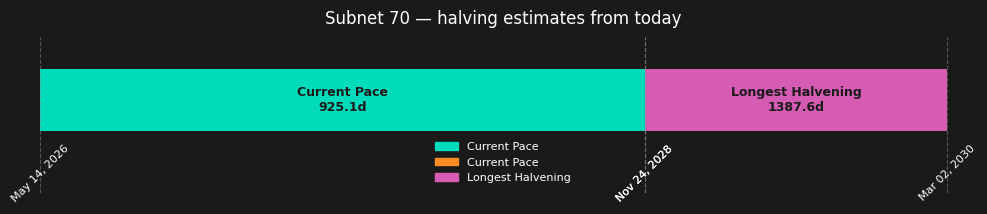

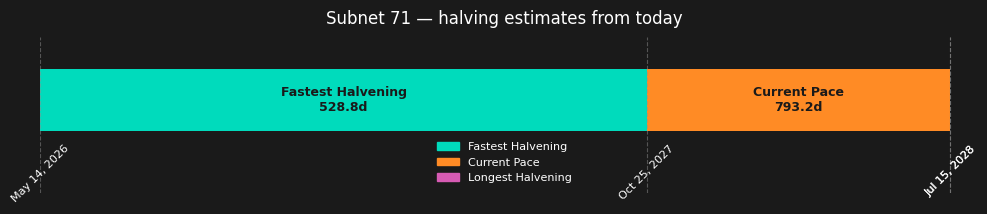

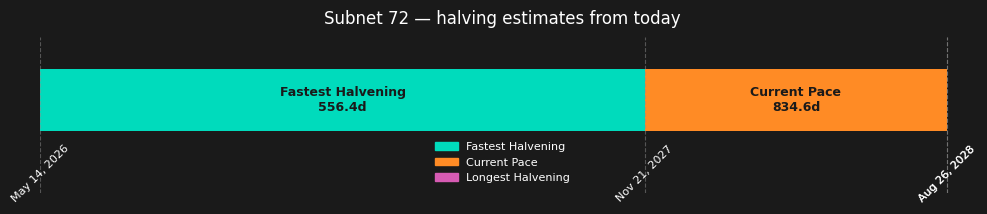

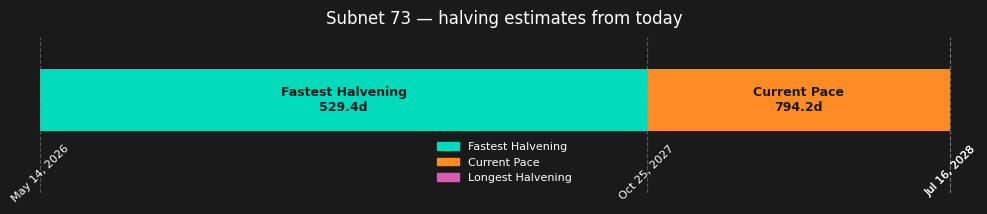

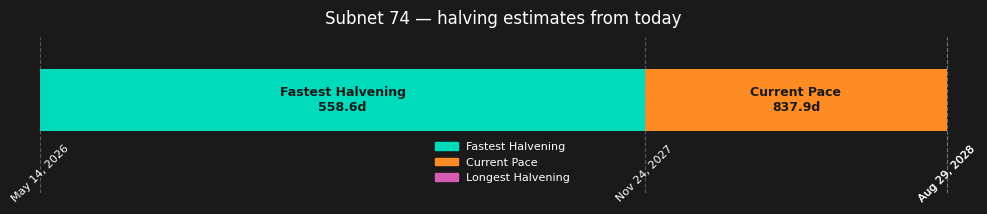

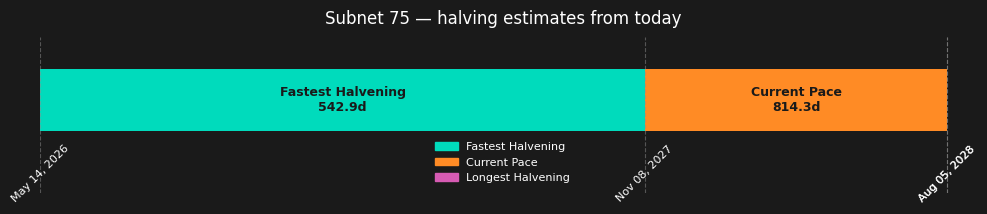

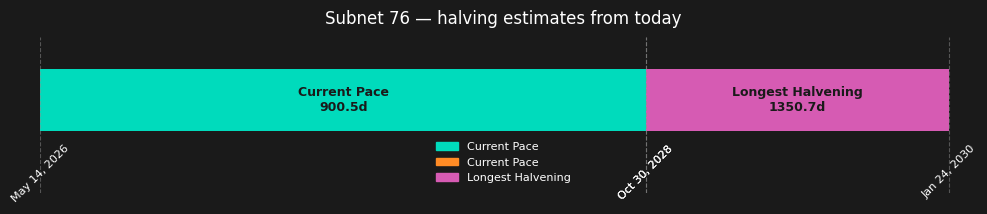

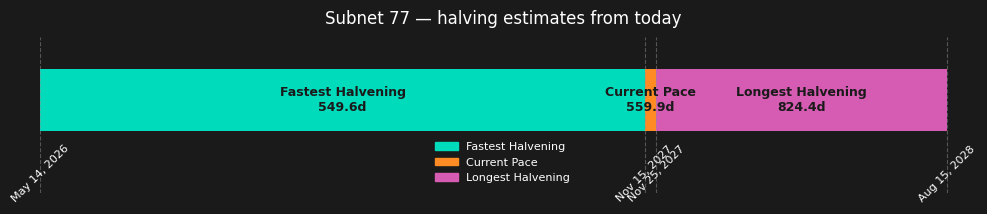

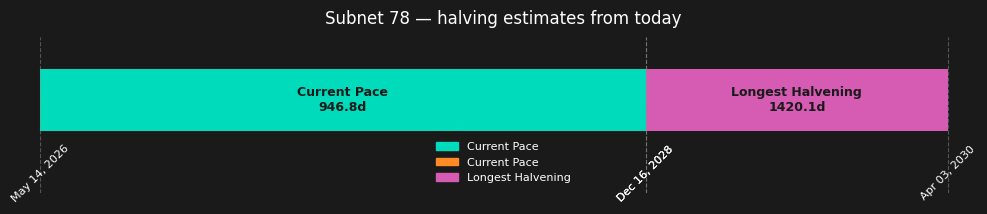

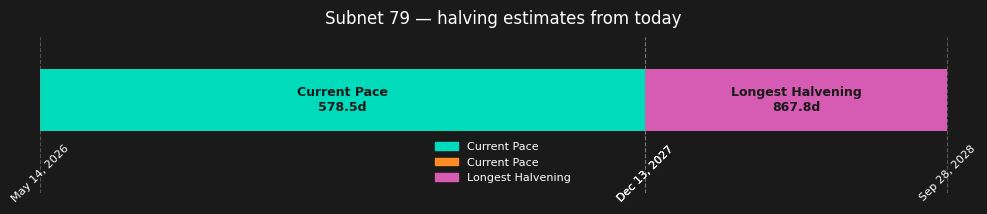

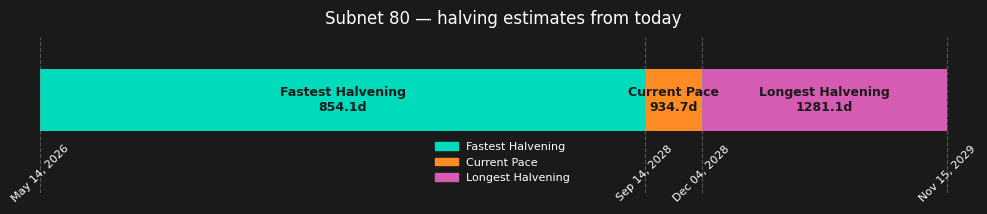

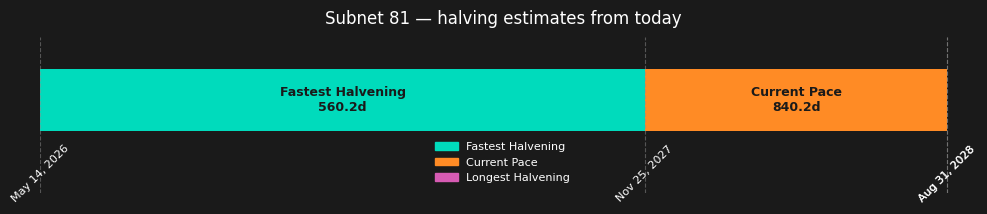

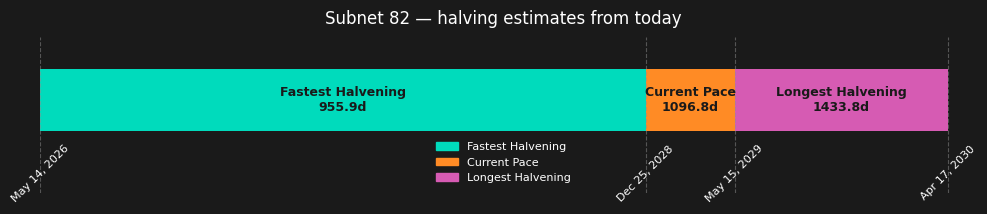

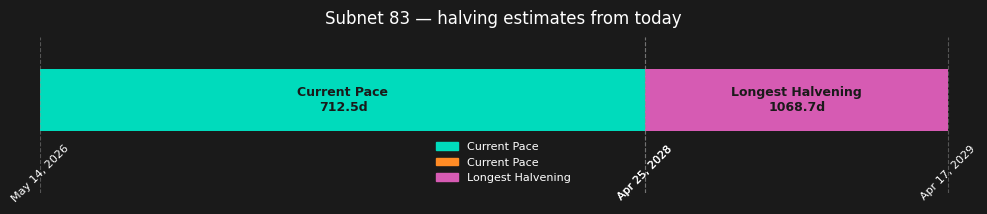

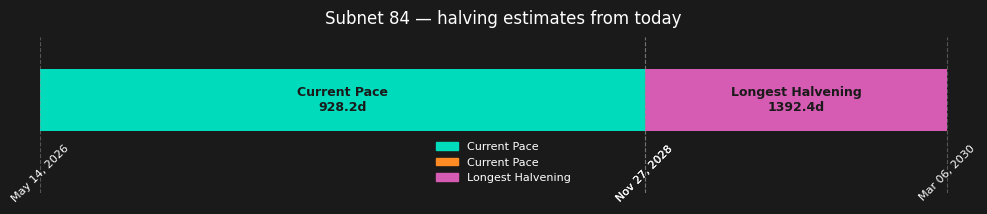

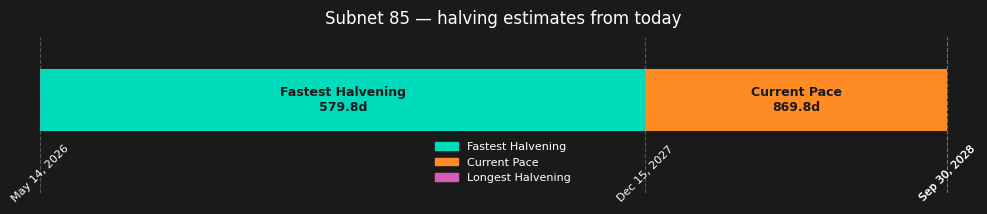

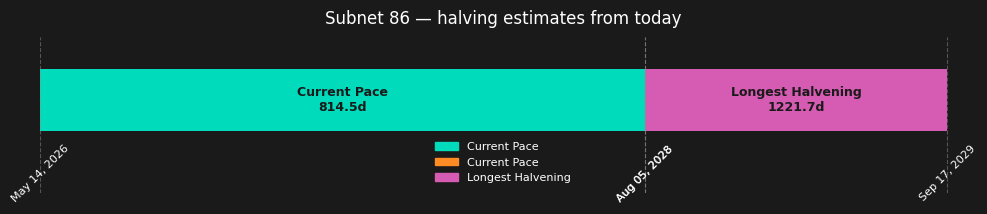

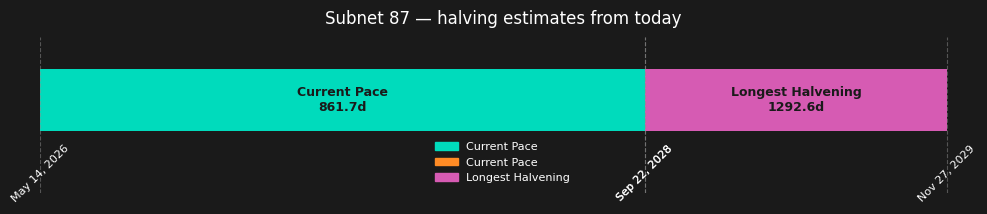

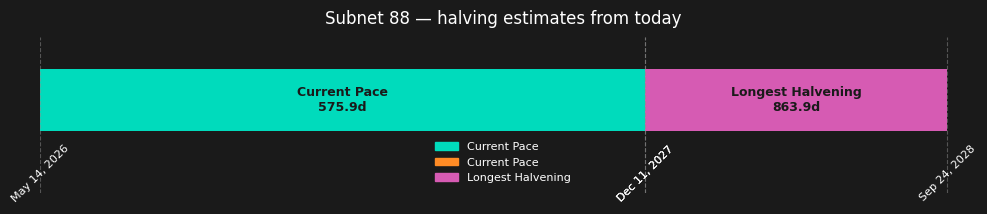

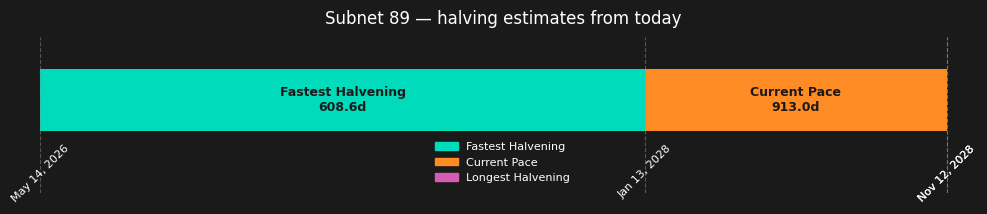

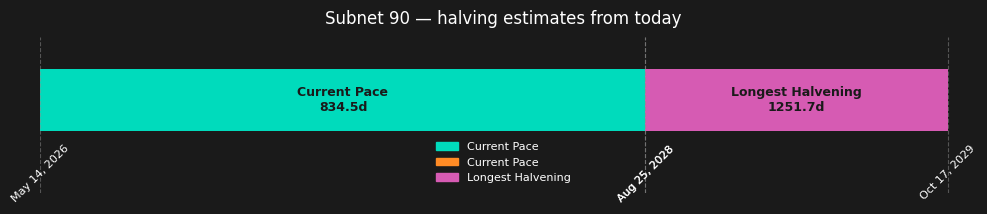

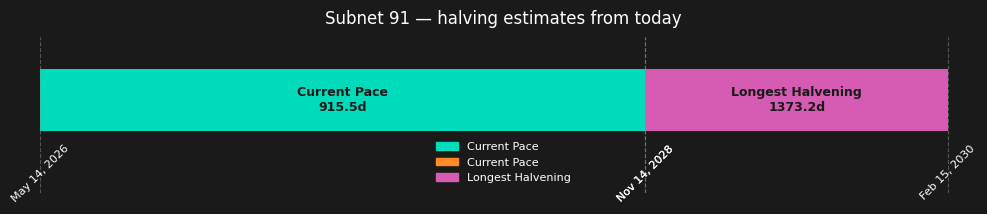

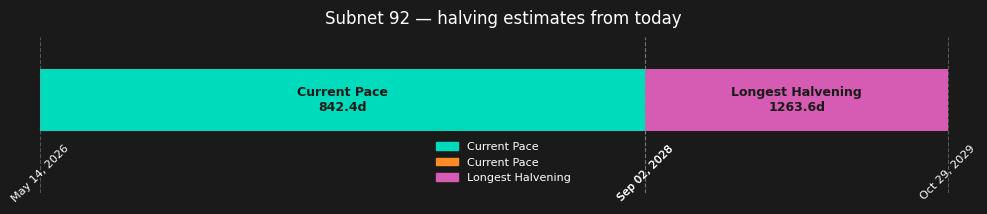

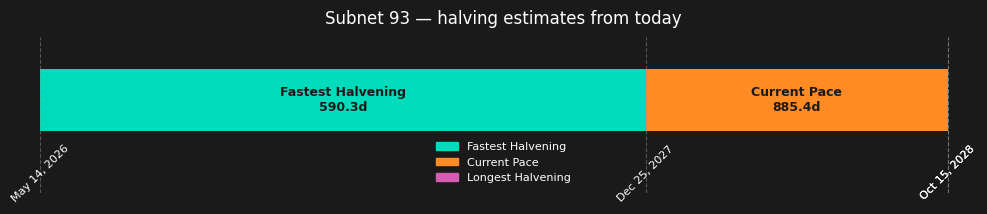

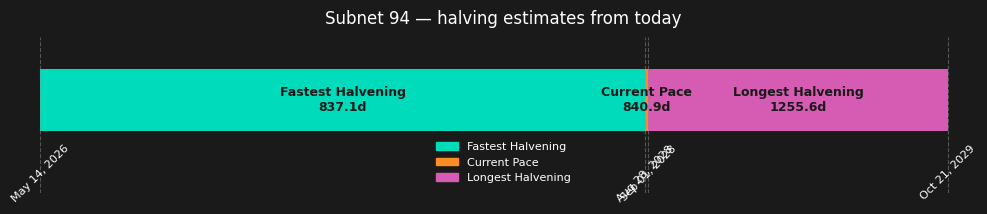

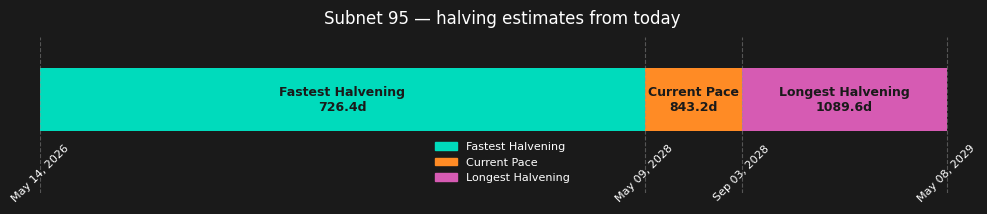

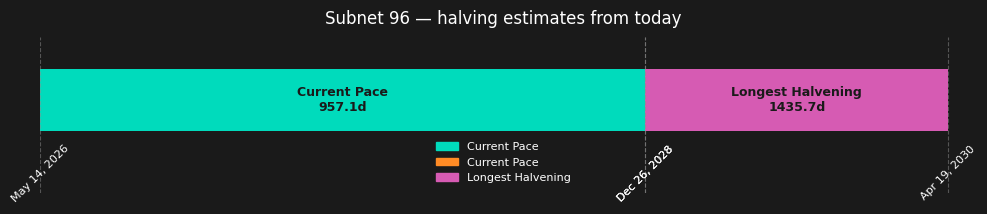

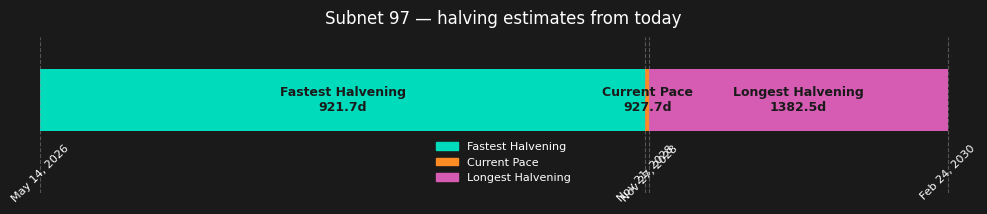

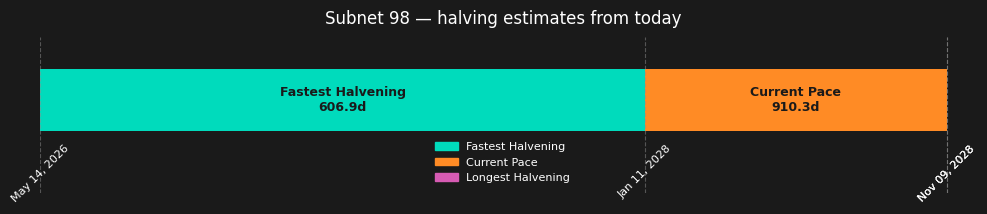

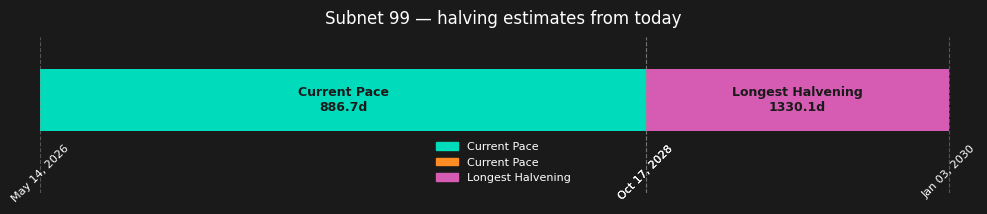

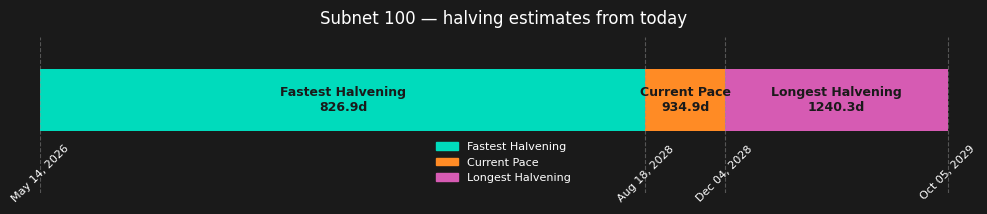

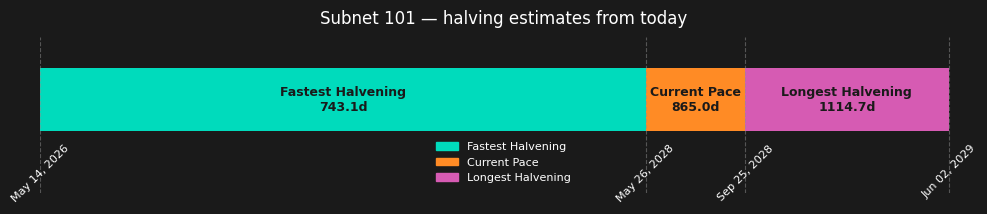

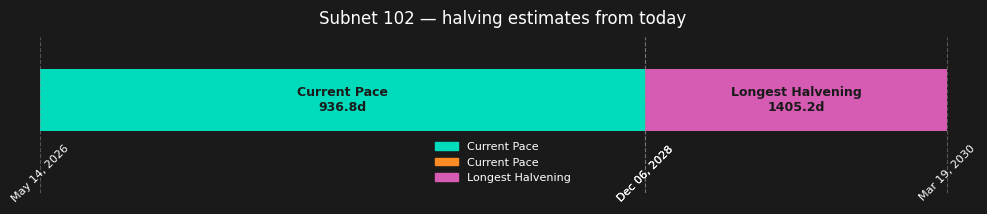

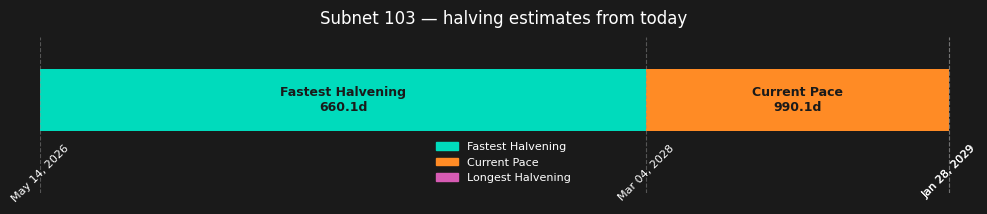

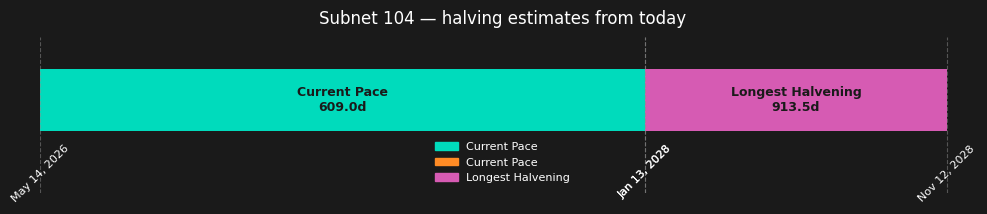

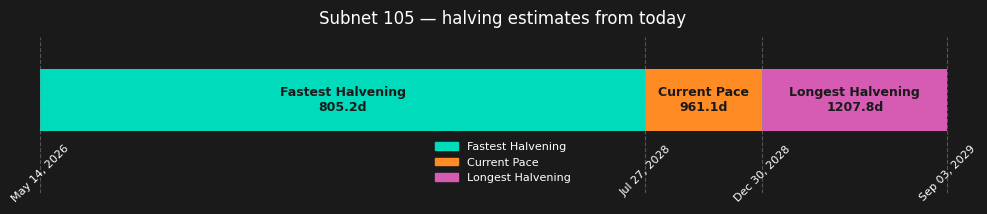

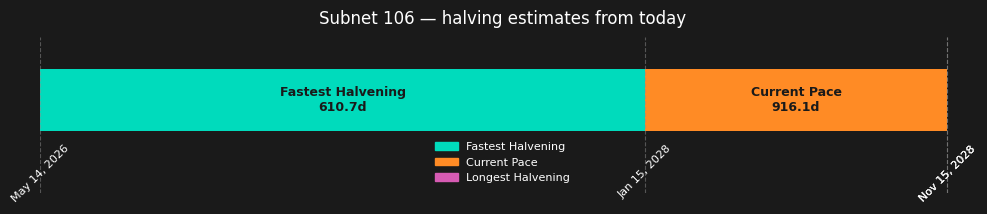

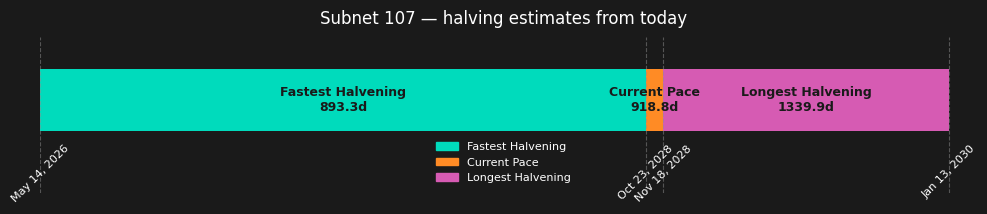

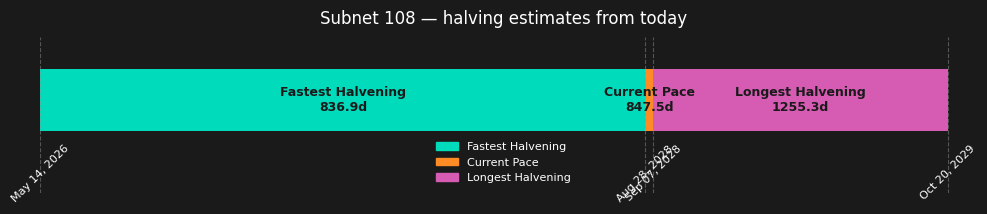

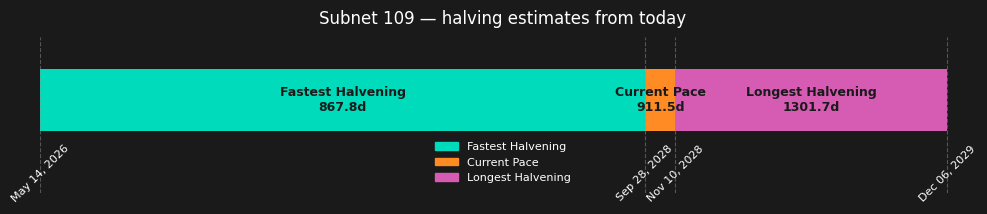

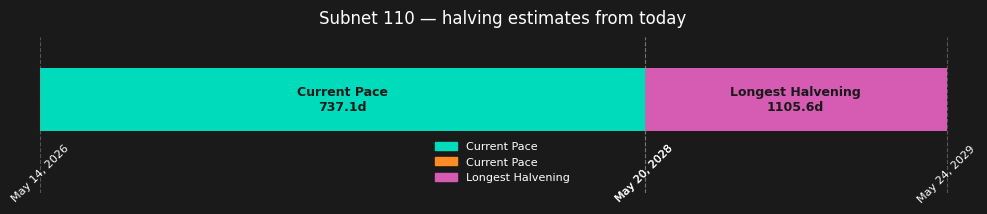

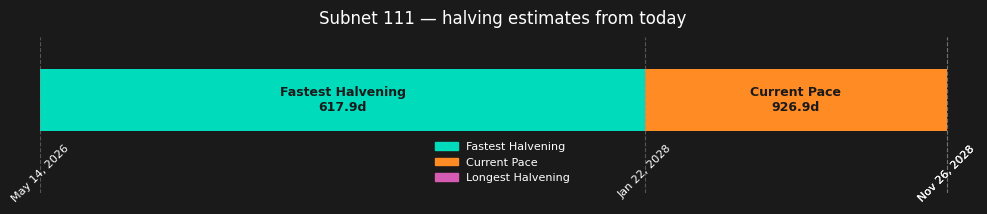

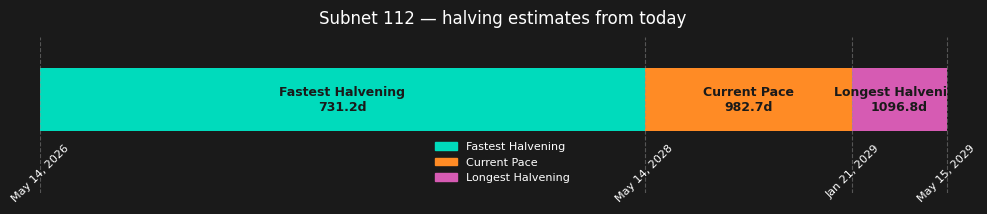

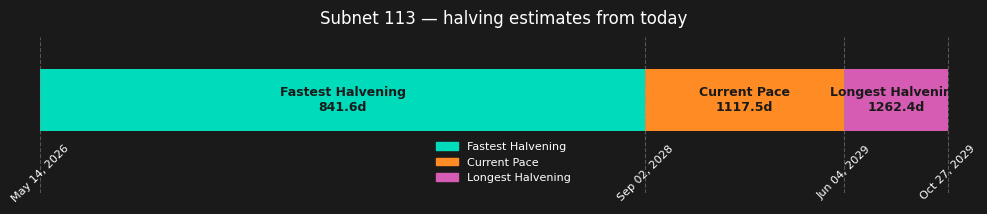

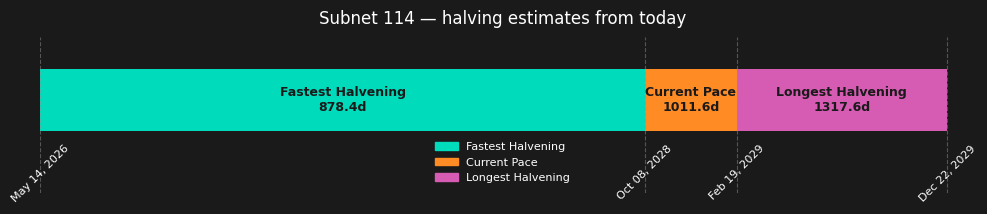

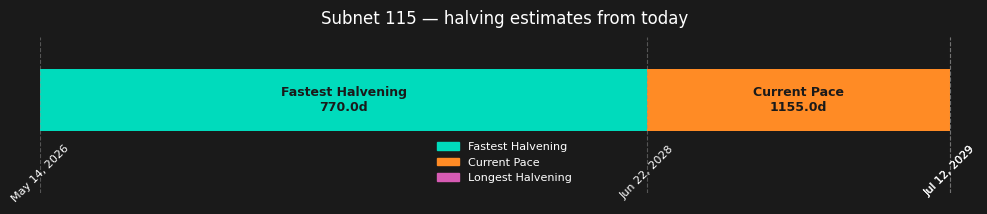

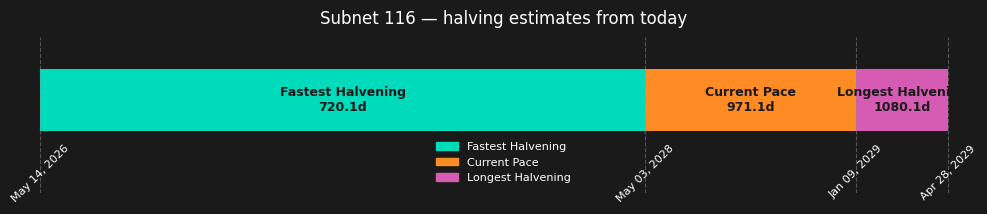

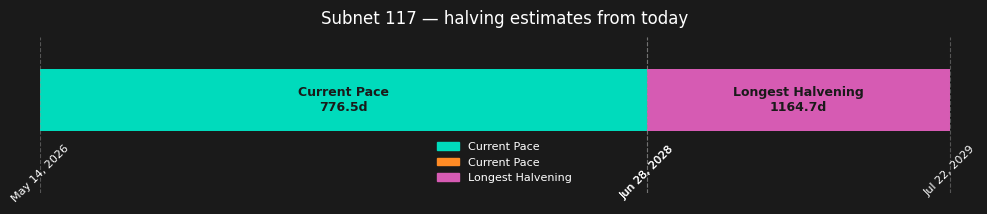

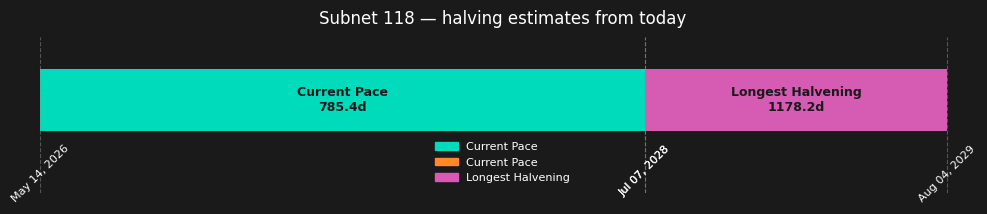

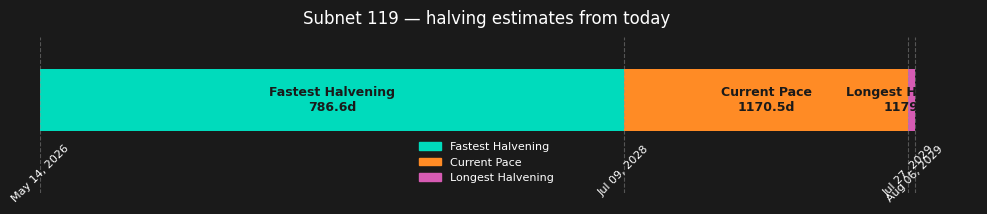

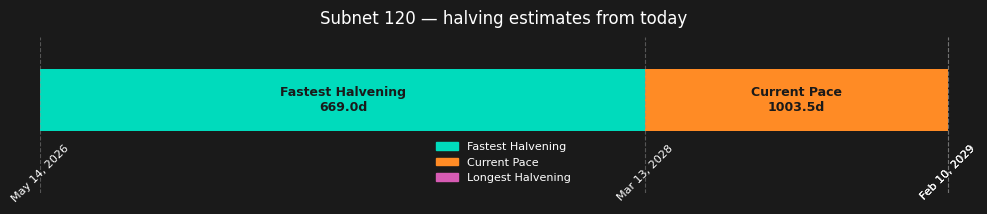

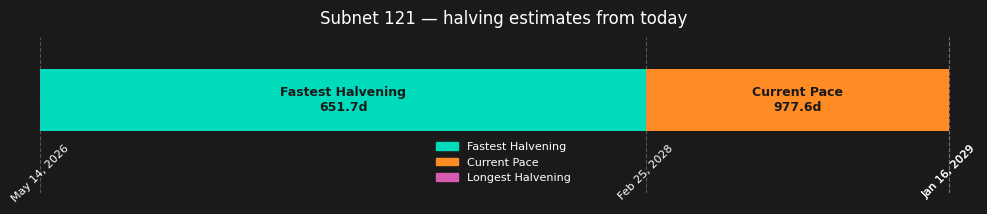

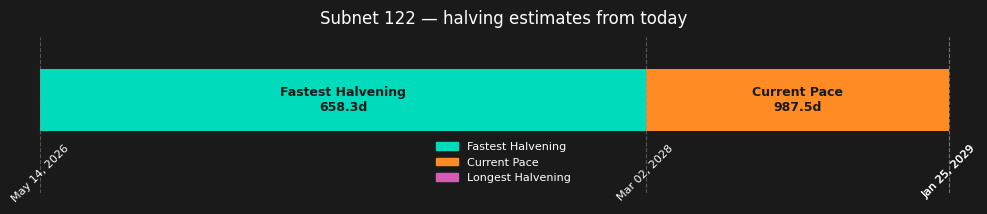

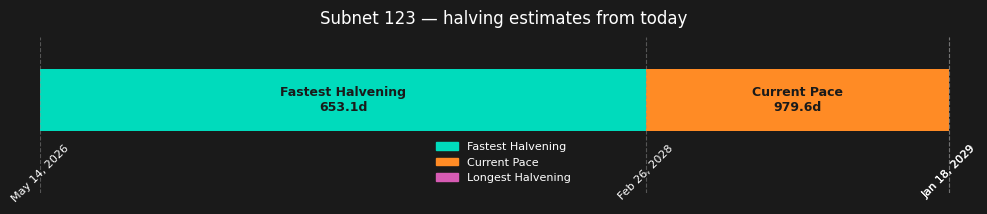

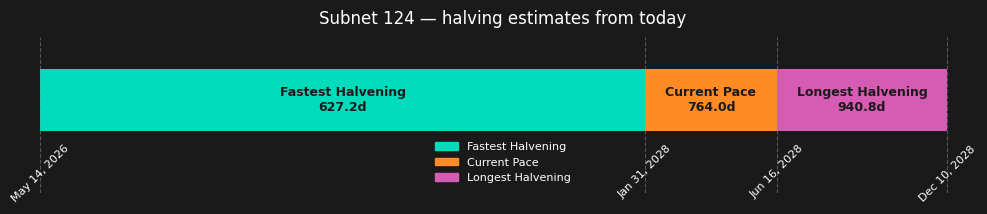

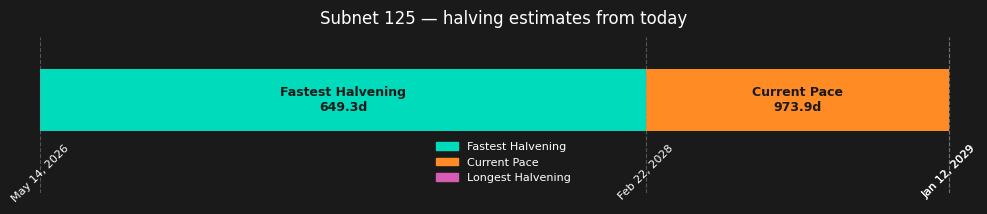

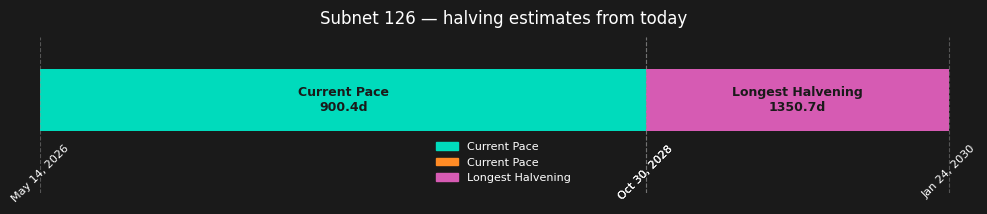

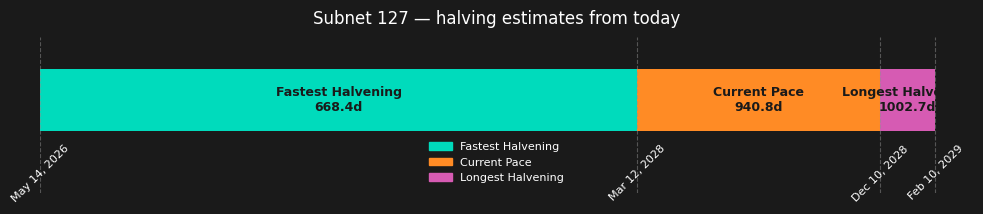

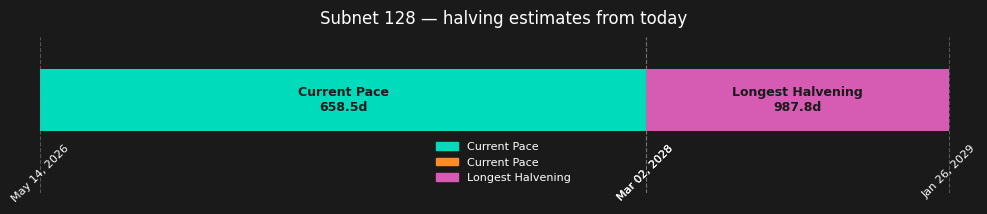

In [63]:
import matplotlib.patches as mpatches


counter =0

while counter < 129:
    
    counter +=1
    netuid = counter
    if netuid not in subnet_halving_days:
        continue
    days = subnet_halving_days[netuid]
    today = datetime.today()

    # Segment widths (gaps between estimates, first from today)
    segments = [days[0], days[1] - days[0], days[2] - days[1]]
    colors   = [ts_teal, ts_orange, ts_purple]
    if segments[1]==0:
        labels   = ['Current Pace', 'Current Pace', 'Longest Halvening']
    else: 
        labels   = ['Fastest Halvening', 'Current Pace', 'Longest Halvening']
    # Boundary dates
    boundaries = [today] + [today + timedelta(d) for d in days]
    date_labels = [d.strftime('%b %d, %Y') for d in boundaries]
    
    fig, ax = plt.subplots(figsize=(10, 2.2))
    fig.patch.set_facecolor('#1a1a1a')
    ax.set_facecolor('#1a1a1a')
    
    left = 0
    bar_y = 0.4
    bar_h = 0.4
    
    for seg, color, label in zip(segments, colors, labels):
        
        if seg>0:
            ax.barh(bar_y, seg, left=left, height=bar_h, color=color, align='edge')
            # Center label inside segment
            ax.text(left + seg / 2, bar_y + bar_h / 2, f'{label}\n{days[labels.index(label)]}d',
                    ha='center', va='center', color='#1a1a1a', fontsize=9, fontweight='bold')
            left += seg
    
    # Date tick marks at each boundary
    boundary_x = [0] + [d for d in days]
    for x, dlabel in zip(boundary_x, date_labels):
        ax.axvline(x, color=ts_gray, linewidth=0.8, linestyle='--', alpha=0.5)
        ax.text(x, bar_y - 0.08, dlabel, ha='center', va='top', color='white', fontsize=8, rotation=45)
    
    ax.set_xlim(0, days[2] * 1.02)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(f'Subnet {netuid} — halving estimates from today', color='white', fontsize=12, pad=10)
    
    legend_patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
    ax.legend(handles=legend_patches, loc='lower center', framealpha=0,
              labelcolor='white', fontsize=8)
    
    plt.tight_layout()
    plt.savefig('halving_chart.png', dpi=150, bbox_inches='tight')
    plt.show()